In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Download the UCI SMS Spam Collection dataset

!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
# Extract the downloaded ZIP file

!unzip -o -q "sms+spam+collection.zip"

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
# Load the SMS Spam Collection dataset

file_path = "SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# Display the first 10 rows

df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


DATASET SHAPE
Number of rows    : 5572
Number of columns : 2

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

COLUMN NAMES
['label', 'message']

MISSING VALUES
label      0
message    0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 403

UNIQUE LABELS
['ham' 'spam']

CLASS DISTRIBUTION
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

DATASET DESCRIPTION
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30

RANDOM SAMPLES


,label,message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...
944,ham,And also I've sorta blown him off a couple tim...
1044,ham,Mmm thats better now i got a roast down me! i...
2484,ham,Mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...
2973,ham,Sary just need Tim in the bollox &it hurt him ...
2991,ham,"Love isn't a decision, it's a feeling. If we c..."
2942,ham,My supervisor find 4 me one lor i thk his stud...
230,ham,Dear good morning now only i am up
1181,ham,I'm in chennai velachery:)


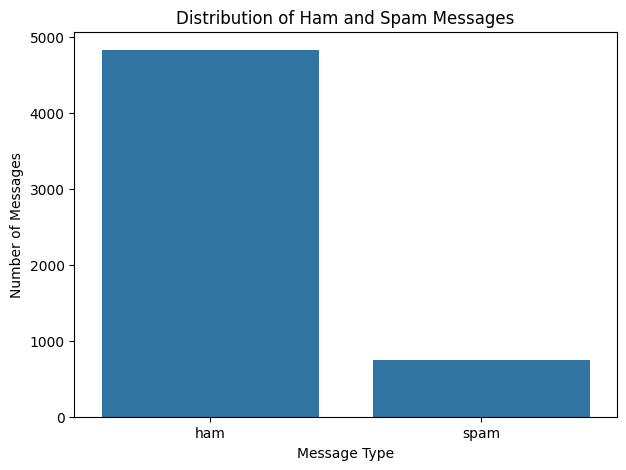

In [6]:
# ============================================================
# BLOCK 2 — DATASET UNDERSTANDING & DATA QUALITY CHECK
# ============================================================

# 1. Dataset dimensions
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


# 2. Column information
print("\n" + "=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
print(df.info())


# 3. Check column names
print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())


# 4. Check missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())


# 5. Check duplicate rows
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


# 6. Check label values
print("\n" + "=" * 60)
print("UNIQUE LABELS")
print("=" * 60)
print(df["label"].unique())


# 7. Class distribution
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

label_counts = df["label"].value_counts()

print(label_counts)

print("\nClass percentages:")
print((df["label"].value_counts(normalize=True) * 100).round(2))


# 8. Basic dataset statistics
print("\n" + "=" * 60)
print("DATASET DESCRIPTION")
print("=" * 60)

print(df.describe(include="all"))


# 9. Display random samples
print("\n" + "=" * 60)
print("RANDOM SAMPLES")
print("=" * 60)

display(df.sample(10, random_state=42))

# 10. Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [7]:
# ============================================================
# BLOCK 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Create basic text-based features

df["character_count"] = df["message"].apply(len)

df["word_count"] = df["message"].apply(
    lambda x: len(x.split())
)

df["sentence_count"] = df["message"].apply(
    lambda x: len(x.split("."))
)

# Display the new features
display(df.head())

,label,message,character_count,word_count,sentence_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,9
1,ham,Ok lar... Joking wif u oni...,29,6,7
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,ham,U dun say so early hor... U c already then say...,49,11,7
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [8]:
# Statistical summary of message characteristics

print("=" * 70)
print("TEXT STATISTICS")
print("=" * 70)

text_stats = df[
    ["character_count", "word_count", "sentence_count"]
].describe()

display(text_stats)

TEXT STATISTICS


,character_count,word_count,sentence_count
count,5572.000000,5572.000000,5572.000000
mean,80.489950,15.597452,3.012563
std,59.942907,11.404053,2.651719
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,62.000000,12.000000,2.000000
75%,122.000000,23.000000,4.000000
max,910.000000,171.000000,42.000000


In [9]:
# Compare text statistics between ham and spam

print("=" * 70)
print("HAM vs SPAM — TEXT STATISTICS")
print("=" * 70)

comparison = df.groupby("label")[
    ["character_count", "word_count", "sentence_count"]
].agg(["mean", "median", "min", "max"])

display(comparison)

HAM vs SPAM — TEXT STATISTICS


character_count                 word_count                  \
                 mean median min  max       mean median min  max   
label                                                              
ham         71.482487   52.0   2  910  14.310259   11.0   1  171   
spam       138.670683  149.0  13  223  23.911647   25.0   2   35   

      sentence_count                 
                mean median min max  
label                                
ham         2.999585    2.0   1  42  
spam        3.096386    3.0   1  14

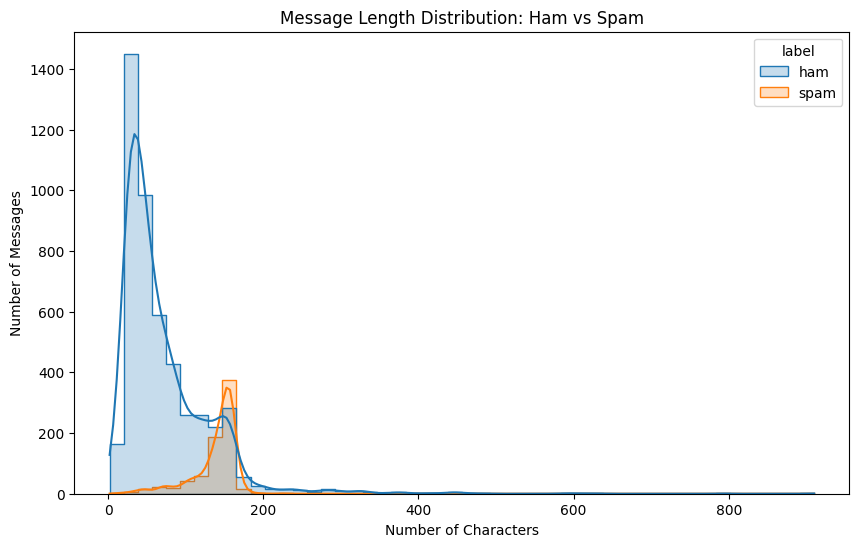

In [10]:
# Distribution of message character count

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="character_count",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Message Length Distribution: Ham vs Spam")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Messages")

plt.show()

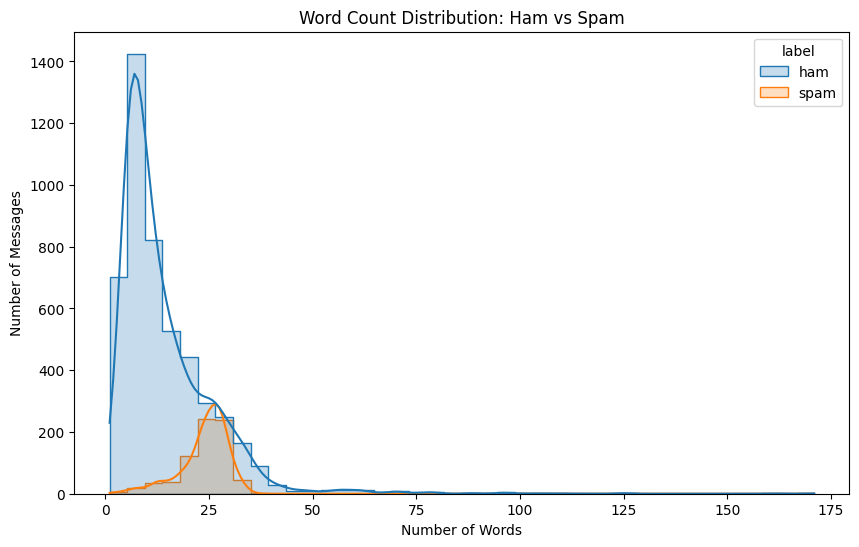

In [11]:
# Distribution of word count

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Word Count Distribution: Ham vs Spam")
plt.xlabel("Number of Words")
plt.ylabel("Number of Messages")

plt.show()

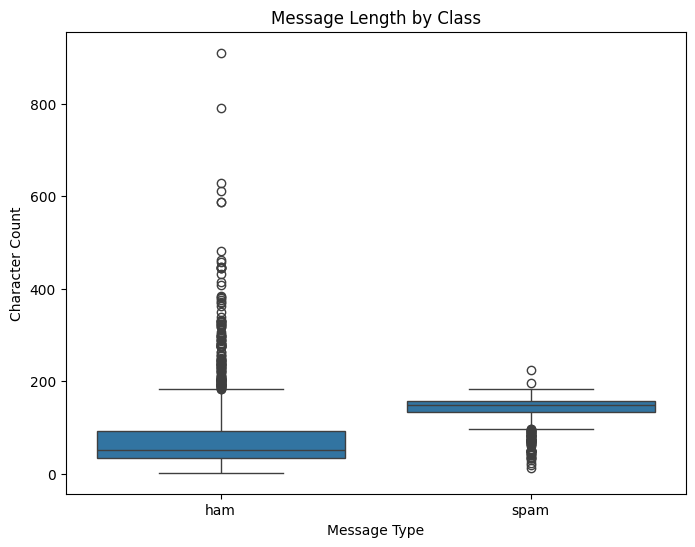

In [12]:
# Compare message lengths using boxplots

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="label",
    y="character_count"
)

plt.title("Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Character Count")

plt.show()

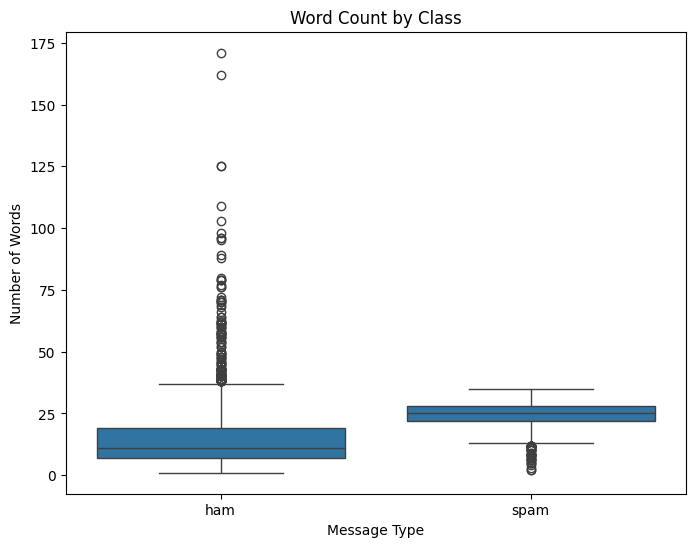

In [13]:
# Compare word counts using boxplots

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by Class")
plt.xlabel("Message Type")
plt.ylabel("Number of Words")

plt.show()

In [14]:
# Display the 10 longest messages

longest_messages = df.sort_values(
    by="character_count",
    ascending=False
).head(10)

display(
    longest_messages[
        ["label", "message", "character_count", "word_count"]
    ]
)

,label,message,character_count,word_count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2849,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
5104,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96


In [15]:
from collections import Counter
import re

# Combine all messages into one text
all_text = " ".join(df["message"].astype(str))

# Extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Count words
word_counts = Counter(words)

# Display the 20 most common words
print("Top 20 most common words:")

for word, count in word_counts.most_common(20):
    print(f"{word:<15} {count}")

Top 20 most common words:
i               3021
to              2253
you             2245
a               1450
the             1339
u               1207
and             980
in              903
is              897
me              807
my              766
it              752
for             711
your            681
of              623
call            593
that            586
s               580
have            578
on              538


In [16]:
# Get spam messages only

spam_text = " ".join(
    df[df["label"] == "spam"]["message"].astype(str)
)

spam_words = re.findall(
    r"\b[a-zA-Z]+\b",
    spam_text.lower()
)

spam_word_counts = Counter(spam_words)

print("Top 20 words in SPAM messages:")

for word, count in spam_word_counts.most_common(20):
    print(f"{word:<15} {count}")

Top 20 words in SPAM messages:
to              691
a               380
call            355
you             297
your            264
free            224
the             206
for             204
now             199
or              188
u               174
txt             163
is              158
on              145
ur              144
have            135
from            131
mobile          127
text            125
stop            123


In [17]:
# Get ham messages only

ham_text = " ".join(
    df[df["label"] == "ham"]["message"].astype(str)
)

ham_words = re.findall(
    r"\b[a-zA-Z]+\b",
    ham_text.lower()
)

ham_word_counts = Counter(ham_words)

print("Top 20 words in HAM messages:")

for word, count in ham_word_counts.most_common(20):
    print(f"{word:<15} {count}")

Top 20 words in HAM messages:
i               2960
you             1948
to              1562
the             1133
a               1070
u               1033
and             858
in              823
me              777
my              754
is              739
it              718
that            560
of              526
for             507
s               490
have            443
can             441
but             441
so              436


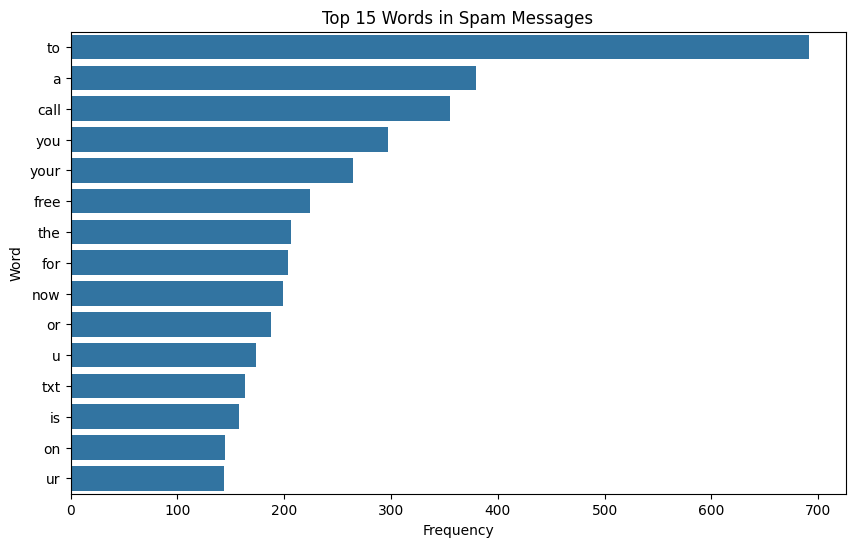

In [18]:
# Visualize most common words in spam messages

spam_top_words = spam_word_counts.most_common(15)

spam_words_df = pd.DataFrame(
    spam_top_words,
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=spam_words_df,
    x="count",
    y="word"
)

plt.title("Top 15 Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [19]:
# ============================================================
# BLOCK 4 — TEXT PREPROCESSING
# ============================================================

import re
import string

print("Text preprocessing libraries imported successfully!")

Text preprocessing libraries imported successfully!


In [20]:
def clean_text(text):
    """
    Clean an SMS message for NLP processing.
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


print("Text cleaning function created successfully!")

Text cleaning function created successfully!


In [21]:
# Create a new column instead of modifying the original message

df["clean_message"] = df["message"].apply(clean_text)

print("Text preprocessing completed!")

Text preprocessing completed!


In [22]:
# Compare original and cleaned messages

comparison = df[
    ["label", "message", "clean_message"]
].sample(10, random_state=42)

display(comparison)

,label,message,clean_message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...,squeeeeeze this is christmas hug if u lik my f...
944,ham,And also I've sorta blown him off a couple tim...,and also ive sorta blown him off a couple time...
1044,ham,Mmm thats better now i got a roast down me! i...,mmm thats better now i got a roast down me id...
2484,ham,Mm have some kanji dont eat anything heavy ok,mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...,so theres a ring that comes with the guys cost...
2973,ham,Sary just need Tim in the bollox &it hurt him ...,sary just need tim in the bollox it hurt him a...
2991,ham,"Love isn't a decision, it's a feeling. If we c...",love isnt a decision its a feeling if we could...
2942,ham,My supervisor find 4 me one lor i thk his stud...,my supervisor find 4 me one lor i thk his stud...
230,ham,Dear good morning now only i am up,dear good morning now only i am up
1181,ham,I'm in chennai velachery:),im in chennai velachery


In [27]:
# Check whether preprocessing created any empty messages

empty_messages = (df["clean_message"].str.len() == 0).sum()

print(f"Empty cleaned messages: {empty_messages}")

Empty cleaned messages: 2


In [24]:
# Check the resulting dataset

print("=" * 60)
print("DATASET AFTER TEXT PREPROCESSING")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head(10))

DATASET AFTER TEXT PREPROCESSING
Rows    : 5572
Columns : 6


,label,message,character_count,word_count,sentence_count,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,9,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,29,6,7,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,11,7,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah i dont think he goes to usf he lives aroun...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,147,32,2,freemsg hey there darling its been 3 weeks now...
6,ham,Even my brother is not like to speak with me. ...,77,16,3,even my brother is not like to speak with me t...
7,ham,As per your request 'Melle Melle (Oru Minnamin...,160,26,2,as per your request melle melle oru minnaminun...
8,spam,WINNER!! As a valued network customer you have...,157,26,4,winner as a valued network customer you have b...
9,spam,Had your mobile 11 months or more? U R entitle...,154,29,1,had your mobile 11 months or more u r entitled...


In [25]:
# ============================================================
# CHECK THE EMPTY CLEANED MESSAGES
# ============================================================

empty_df = df[df["clean_message"].str.len() == 0]

print(f"Number of empty cleaned messages: {len(empty_df)}")

display(
    empty_df[
        ["label", "message", "clean_message"]
    ]
)

Number of empty cleaned messages: 2


,label,message,clean_message
3376,ham,:),
4824,ham,:-) :-),


In [30]:
# ============================================================
# IMPROVED TEXT PREPROCESSING FUNCTION
# ============================================================

def clean_text(text):
    """
    Clean SMS text while preserving meaningful information.
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Replace URLs with a token
    text = re.sub(r"http\S+|www\S+|https\S+", " URL ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Preserve common emoticons before punctuation cleaning
    text = text.replace(":-)", " EMOTICON_HAPPY ")
    text = text.replace(":)", " EMOTICON_HAPPY ")
    text = text.replace(":D", " EMOTICON_HAPPY ")
    text = text.replace(":-(", " EMOTICON_SAD ")
    text = text.replace(":(", " EMOTICON_SAD ")

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [31]:
# Check previously empty messages

empty_df = df[df["clean_message"].str.len() == 0]

print(f"Number of empty cleaned messages: {len(empty_df)}")

display(
    df.loc[
        [3376, 4824],
        ["label", "message", "clean_message"]
    ]
)

Number of empty cleaned messages: 2


,label,message,clean_message
3376,ham,:),
4824,ham,:-) :-),


In [32]:
# ============================================================
# FINALIZE BLOCK 4 — HANDLE EMOTICON-ONLY MESSAGES
# ============================================================

# Remove messages that became empty after preprocessing
before = len(df)

df = df[df["clean_message"].str.strip() != ""].copy()

after = len(df)

print(f"Rows before removal : {before}")
print(f"Rows after removal  : {after}")
print(f"Rows removed        : {before - after}")

# Verify
print("\nEmpty cleaned messages:",
      (df["clean_message"].str.strip() == "").sum())

Rows before removal : 5572
Rows after removal  : 5570
Rows removed        : 2

Empty cleaned messages: 0


In [33]:
# ============================================================
# BLOCK 5 — TRAIN/TEST SPLIT + TF-IDF
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------------------------------------
# 1. Encode labels
# ------------------------------------------------------------

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Label encoding:")
print(df[["label", "label_encoded"]].drop_duplicates())


# ------------------------------------------------------------
# 2. Separate features and target
# ------------------------------------------------------------

X = df["clean_message"]
y = df["label_encoded"]


# ------------------------------------------------------------
# 3. Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDataset split:")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


# ------------------------------------------------------------
# 4. Create TF-IDF Vectorizer
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)


# ------------------------------------------------------------
# 5. Fit TF-IDF ONLY on training data
# ------------------------------------------------------------

X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the already-fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)


# ------------------------------------------------------------
# 6. Inspect feature matrices
# ------------------------------------------------------------

print("\nTF-IDF feature matrices:")
print(f"Training shape : {X_train_tfidf.shape}")
print(f"Testing shape  : {X_test_tfidf.shape}")

print(f"\nNumber of TF-IDF features: {len(tfidf.get_feature_names_out())}")


# ------------------------------------------------------------
# 7. Display some learned features
# ------------------------------------------------------------

features = tfidf.get_feature_names_out()

print("\nFirst 30 TF-IDF features:")
print(features[:30])

Label encoding:
  label  label_encoded
0   ham              0
2  spam              1

Dataset split:
Training samples : 4456
Testing samples  : 1114

TF-IDF feature matrices:
Training shape : (4456, 5000)
Testing shape  : (1114, 5000)

Number of TF-IDF features: 5000

First 30 TF-IDF features:
['020603' '020603 this' '07xxxxxxxxx' '0800' '0800 542' '08000839402'
 '08000839402 or' '08000930705' '08000930705 for' '08001950382'
 '08001950382 or' '0808' '0808 145' '08452810073' '08452810073 for' '0870'
 '0870 is' '08701417012' '08701417012 profit' '08707509020'
 '08707509020 just' '08712300220' '08712300220 quoting' '08712460324'
 '08715705022' '08718720201' '09050090044' '09050090044 now' '10' '100']


In [34]:
# ============================================================
# BLOCK 6 — MODEL TRAINING & INITIAL COMPARISON
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Define models
# ------------------------------------------------------------

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    )
}


# ------------------------------------------------------------
# 2. Train and evaluate each model
# ------------------------------------------------------------

results = []
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    trained_models[name] = model

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")


# ------------------------------------------------------------
# 3. Create comparison table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.sort_values(
        by="F1-Score",
        ascending=False
    ).reset_index(drop=True)
)


Training Naive Bayes...
Accuracy  : 0.9668
Precision : 1.0000
Recall    : 0.7517
F1-Score  : 0.8582

Training Logistic Regression...
Accuracy  : 0.9713
Precision : 1.0000
Recall    : 0.7852
F1-Score  : 0.8797

Training Linear SVM...
Accuracy  : 0.9856
Precision : 0.9716
Recall    : 0.9195
F1-Score  : 0.9448

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.985637,0.971631,0.919463,0.944828
1,Logistic Regression,0.971275,1.000000,0.785235,0.879699
2,Naive Bayes,0.966786,1.000000,0.751678,0.858238


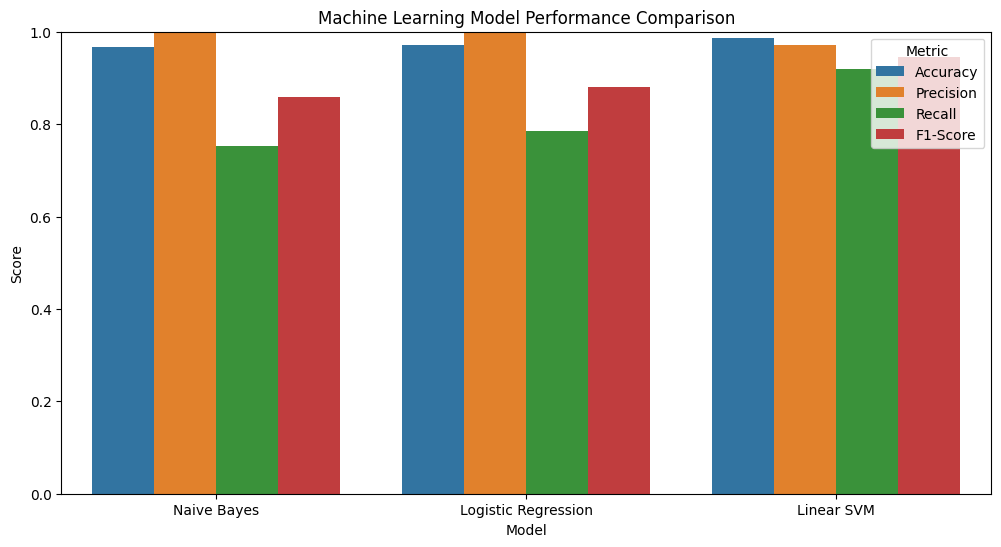

In [35]:
# ------------------------------------------------------------
# 4. Visualize model performance
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.legend(title="Metric")
plt.show()


CLASSIFICATION REPORT — Naive Bayes
              precision    recall  f1-score   support

         Ham     0.9631    1.0000    0.9812       965
        Spam     1.0000    0.7517    0.8582       149

    accuracy                         0.9668      1114
   macro avg     0.9815    0.8758    0.9197      1114
weighted avg     0.9680    0.9668    0.9647      1114


CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

         Ham     0.9679    1.0000    0.9837       965
        Spam     1.0000    0.7852    0.8797       149

    accuracy                         0.9713      1114
   macro avg     0.9840    0.8926    0.9317      1114
weighted avg     0.9722    0.9713    0.9698      1114


CLASSIFICATION REPORT — Linear SVM
              precision    recall  f1-score   support

         Ham     0.9877    0.9959    0.9917       965
        Spam     0.9716    0.9195    0.9448       149

    accuracy                         0.9856      1114
   macro a

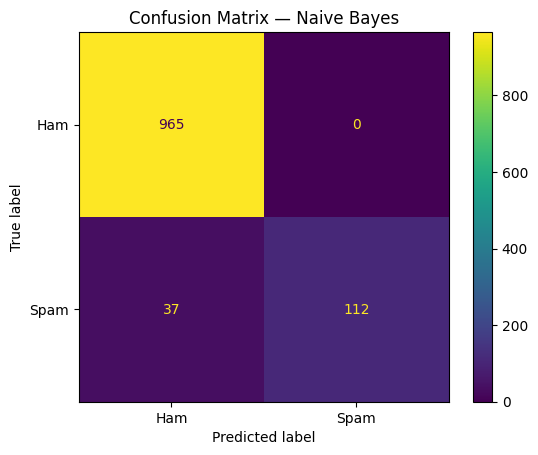


CONFUSION MATRIX — Logistic Regression
[[965   0]
 [ 32 117]]


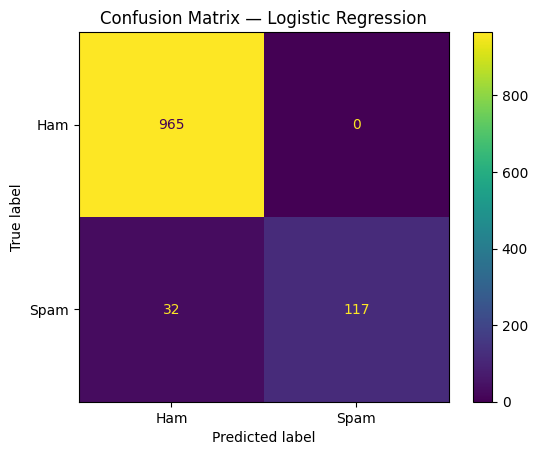


CONFUSION MATRIX — Linear SVM
[[961   4]
 [ 12 137]]


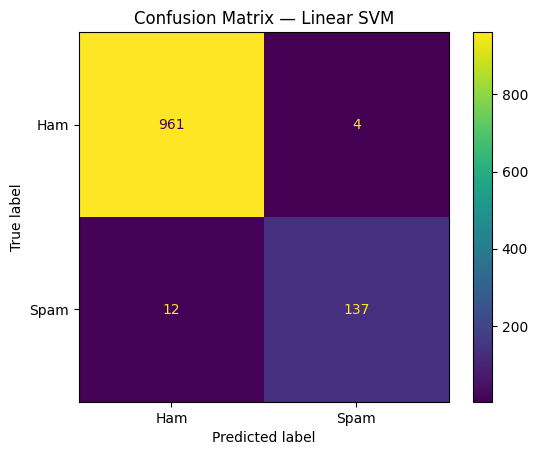

In [36]:
# ============================================================
# BLOCK 7 — DETAILED MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Generate predictions from all trained models
# ------------------------------------------------------------

predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_tfidf)


# ------------------------------------------------------------
# 2. Detailed classification reports
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT — {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"],
            digits=4
        )
    )


# ------------------------------------------------------------
# 3. Confusion matrices
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 70)
    print(f"CONFUSION MATRIX — {name}")
    print("=" * 70)

    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Ham", "Spam"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

In [37]:
# ============================================================
# BLOCK 7B — ERROR ANALYSIS
# ============================================================

# Use Linear SVM for detailed error analysis
best_model_name = "Linear SVM"

best_predictions = predictions[best_model_name]

# Create an evaluation dataframe
error_df = df.loc[X_test.index, [
    "label",
    "message",
    "clean_message"
]].copy()

error_df["actual"] = y_test
error_df["predicted"] = best_predictions

# ------------------------------------------------------------
# False Positives
# ------------------------------------------------------------

false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

print("=" * 70)
print("FALSE POSITIVES — HAM PREDICTED AS SPAM")
print("=" * 70)

print(f"Number of false positives: {len(false_positives)}")

display(
    false_positives[
        ["label", "message", "clean_message"]
    ].head(20)
)


# ------------------------------------------------------------
# False Negatives
# ------------------------------------------------------------

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("\n" + "=" * 70)
print("FALSE NEGATIVES — SPAM PREDICTED AS HAM")
print("=" * 70)

print(f"Number of false negatives: {len(false_negatives)}")

display(
    false_negatives[
        ["label", "message", "clean_message"]
    ].head(20)
)

FALSE POSITIVES — HAM PREDICTED AS SPAM
Number of false positives: 4


,label,message,clean_message
4702,ham,I liked the new mobile,i liked the new mobile
417,ham,Alright i have a new goal now,alright i have a new goal now
153,ham,Ok... Ur typical reply...,ok ur typical reply
1082,ham,Can u get pic msgs to your phone?,can u get pic msgs to your phone



FALSE NEGATIVES — SPAM PREDICTED AS HAM
Number of false negatives: 12


,label,message,clean_message
3981,spam,ringtoneking 84484,ringtoneking 84484
1460,spam,Bought one ringtone and now getting texts cost...,bought one ringtone and now getting texts cost...
751,spam,"Do you realize that in about 40 years, we'll h...",do you realize that in about 40 years well hav...
5030,spam,I'd like to tell you my deepest darkest fantas...,id like to tell you my deepest darkest fantasi...
3360,spam,Sorry I missed your call let's talk when you h...,sorry i missed your call lets talk when you ha...
1430,spam,For sale - arsenal dartboard. Good condition b...,for sale arsenal dartboard good condition but ...
1269,spam,Can U get 2 phone NOW? I wanna chat 2 set up m...,can u get 2 phone now i wanna chat 2 set up me...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been 3 weeks now...
731,spam,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,email alertfrom jeri stewartsize 2kbsubject lo...
2823,spam,ROMCAPspam Everyone around should be respondin...,romcapspam everyone around should be respondin...


In [38]:
# ============================================================
# BLOCK 8 — LINEAR SVM HYPERPARAMETER TUNING
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Test different C values
# ------------------------------------------------------------

C_values = [0.5, 1, 2, 5]

svm_results = []
svm_models = {}

for C in C_values:

    model = LinearSVC(
        C=C,
        random_state=42
    )

    # Train
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    svm_results.append({
        "C": C,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    svm_models[C] = model


# ------------------------------------------------------------
# 2. Comparison table
# ------------------------------------------------------------

svm_results_df = pd.DataFrame(svm_results)

print("=" * 70)
print("LINEAR SVM HYPERPARAMETER COMPARISON")
print("=" * 70)

display(
    svm_results_df.sort_values(
        by="F1-Score",
        ascending=False
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Select best model based on F1-score
# ------------------------------------------------------------

best_C = svm_results_df.loc[
    svm_results_df["F1-Score"].idxmax(),
    "C"
]

best_svm = svm_models[best_C]

print(f"\nBest C value: {best_C}")
print("Best model selected based on F1-score.")

LINEAR SVM HYPERPARAMETER COMPARISON


,C,Accuracy,Precision,Recall,F1-Score
0,2.0,0.986535,0.971831,0.926174,0.948454
1,5.0,0.985637,0.958621,0.932886,0.945578
2,1.0,0.985637,0.971631,0.919463,0.944828
3,0.5,0.984740,0.978261,0.906040,0.940767



Best C value: 2.0
Best model selected based on F1-score.


FINAL MODEL — LINEAR SVM
              precision    recall  f1-score   support

         Ham     0.9887    0.9959    0.9923       965
        Spam     0.9718    0.9262    0.9485       149

    accuracy                         0.9865      1114
   macro avg     0.9803    0.9610    0.9704      1114
weighted avg     0.9864    0.9865    0.9864      1114


Confusion Matrix:
[[961   4]
 [ 11 138]]


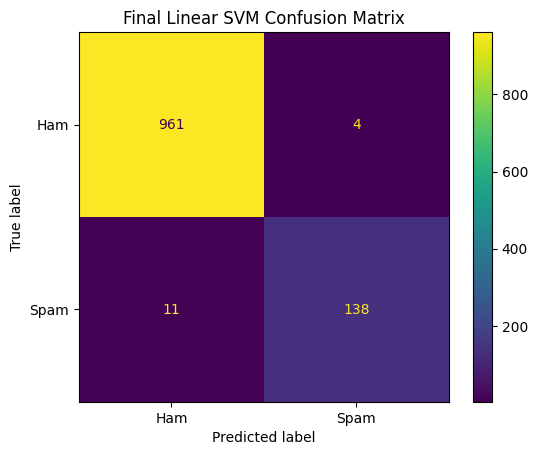

In [39]:
# ============================================================
# FINAL SVM EVALUATION
# ============================================================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final predictions
final_predictions = best_svm.predict(X_test_tfidf)

print("=" * 70)
print("FINAL MODEL — LINEAR SVM")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Ham", "Spam"],
        digits=4
    )
)

# Confusion matrix
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("\nConfusion Matrix:")
print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Final Linear SVM Confusion Matrix")
plt.show()

In [41]:
# ============================================================
# BLOCK 9 — BUILD THE FINAL SPAM PREDICTION SYSTEM
# ============================================================

def predict_message(message):
    """
    Predict whether a new SMS message is Ham or Spam.
    """

    # Step 1: Clean the message
    cleaned_message = clean_text(message)

    # Step 2: Convert text into TF-IDF features
    message_tfidf = tfidf.transform([cleaned_message])

    # Step 3: Predict using the final trained SVM
    prediction = best_svm.predict(message_tfidf)[0]

    # Step 4: Convert numerical prediction to label
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"


# ------------------------------------------------------------
# Test the prediction system
# ------------------------------------------------------------

test_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are you coming to college tomorrow?",
    "URGENT! You have won 5000 pounds. Claim your reward now!",
    "Can you send me the notes from today's lecture?"
]

print("=" * 70)
print("SMS SPAM DETECTOR — TEST PREDICTIONS")
print("=" * 70)

for message in test_messages:

    prediction = predict_message(message)

    print(f"\nMessage: {message}")
    print(f"Prediction: {prediction}")

SMS SPAM DETECTOR — TEST PREDICTIONS

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM

Message: Hey, are you coming to college tomorrow?
Prediction: HAM

Message: URGENT! You have won 5000 pounds. Claim your reward now!
Prediction: SPAM

Message: Can you send me the notes from today's lecture?
Prediction: HAM


In [43]:
# ============================================================
# INTERACTIVE SMS SPAM DETECTOR
# ============================================================

user_message = input("Enter an SMS message: ")

prediction = predict_message(user_message)

print("\n" + "=" * 50)
print(f"Prediction: {prediction}")
print("=" * 50)

Enter an SMS message: Hey, don't forget we have a lecture at 10 tomorrow.

Prediction: HAM


In [45]:
# ============================================================
# BLOCK 10 — SAVE FINAL MODEL AND TF-IDF VECTORIZER
# ============================================================

import joblib
import os

# Create a folder for saved model files
os.makedirs("spam_detector_model", exist_ok=True)

# Save the trained Linear SVM
joblib.dump(
    best_svm,
    "spam_detector_model/spam_classifier.pkl"
)

# Save the TF-IDF vectorizer
joblib.dump(
    tfidf,
    "spam_detector_model/tfidf_vectorizer.pkl"
)

print("=" * 60)
print("MODEL SAVING COMPLETED")
print("=" * 60)

print("Saved files:")

for file in os.listdir("spam_detector_model"):
    print("✓", file)

MODEL SAVING COMPLETED
Saved files:
✓ spam_classifier.pkl
✓ tfidf_vectorizer.pkl


In [46]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    "spam_detector_model/spam_classifier.pkl"
)

loaded_tfidf = joblib.load(
    "spam_detector_model/tfidf_vectorizer.pkl"
)

test_message = "Congratulations! You have won a free prize. Call now!"

cleaned = clean_text(test_message)

features = loaded_tfidf.transform([cleaned])

prediction = loaded_model.predict(features)[0]

result = "SPAM" if prediction == 1 else "HAM"

print("Test message:")
print(test_message)

print("\nPrediction:", result)

Test message:
Congratulations! You have won a free prize. Call now!

Prediction: SPAM


In [47]:
# ============================================================
# BLOCK 11 — INSTALL GRADIO
# ============================================================

!pip -q install gradio

In [48]:
# ============================================================
# BLOCK 11B — SPAM DETECTOR USER INTERFACE
# ============================================================

import gradio as gr


def detect_spam(message):

    if not message or not message.strip():
        return "Please enter a message."

    # Clean input
    cleaned = clean_text(message)

    # Convert to TF-IDF
    features = tfidf.transform([cleaned])

    # Predict
    prediction = best_svm.predict(features)[0]

    if prediction == 1:
        return "🚨 SPAM MESSAGE"
    else:
        return "✅ HAM — LEGITIMATE MESSAGE"


demo = gr.Interface(
    fn=detect_spam,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter an SMS message here..."
    ),
    outputs=gr.Textbox(
        label="Prediction"
    ),
    title="📧 SMS Spam Detector",
    description="Machine Learning based SMS spam classification using TF-IDF and Linear SVM."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2d415a8d971cc655b3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
